Running TRACTS Colombian model...
Running msprime Colombian simulation...
Extracting tracts...

Plots saved!


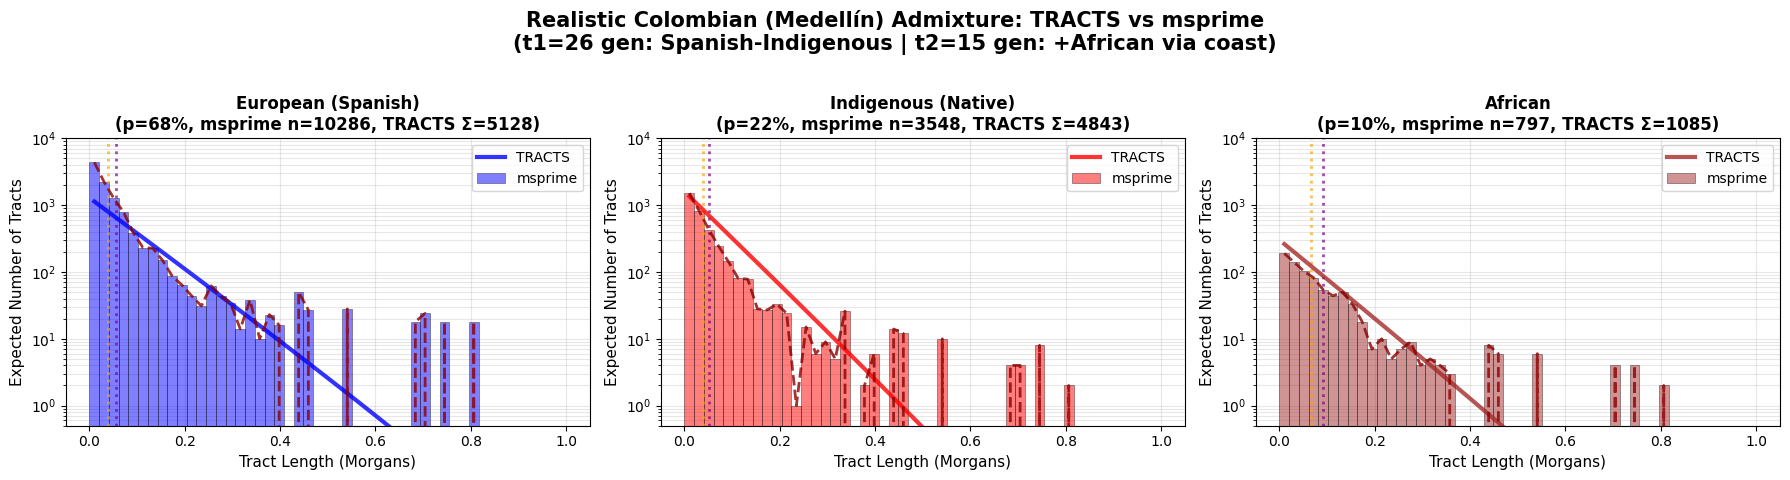


REALISTIC COLOMBIAN (MEDELLÍN) ADMIXTURE
Historical timeline:
  t1=26 gen (~1500 CE): Spanish conquest → European-Indigenous admixture
  t2=15 gen (~1700 CE): African slaves arrive via Pacific/Caribbean coast

Target ancestry proportions (matching 1000 Genomes):
  European: 68%
  Indigenous: 22%
  African: 10%

European (Spanish):
  msprime: n=10286 tracts, mean=0.0547 M
  TRACTS: Σ=5128 expected tracts
  Agreement: 0.50x
  Theoretical mean (1/26): 0.0385 M

Indigenous (Native):
  msprime: n=3548 tracts, mean=0.0513 M
  TRACTS: Σ=4843 expected tracts
  Agreement: 1.37x
  Theoretical mean (1/26): 0.0385 M

African:
  msprime: n=797 tracts, mean=0.0911 M
  TRACTS: Σ=1085 expected tracts
  Agreement: 1.36x
  Theoretical mean (1/15): 0.0667 M

NOTE: African tracts are shorter on average (more recent admixture)
      European/Indigenous tracts are longer (older admixture)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False

# ============================================================================
# REALISTIC COLOMBIAN (MEDELLÍN) 3-WAY ADMIXTURE
# Based on historical records and 1000 Genomes data
# ============================================================================

# Timeline (generations at ~20 years/gen)
t1 = 26  # ~1500 CE - Spanish conquest, immediate European-Indigenous admixture
t2 = 15  # ~1700 CE - Peak African slave trade to Colombia (via Cartagena/Pacific coast)

# Target proportions matching Medellín genomic data
p_european = 0.68    # 68% European
p_indigenous = 0.22  # 22% Indigenous  
p_african = 0.10     # 10% African

sequence_length = 1e8
r = 1e-8
Ne = 10000
sample_size = 200
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS: REALISTIC COLOMBIAN MODEL
# ============================================================================
def run_tracts_colombian_realistic():
    """
    Realistic Colombian (Medellín) admixture:
    - t1=26 gen: Spanish-Indigenous contact (founding event)
    - t2=15 gen: African admixture arrives (smaller proportion in interior)
    """
    if not HAS_TRACTS:
        return None, None, None
    
    mig = np.zeros((t1 + 1, 3))  # 0=European, 1=Indigenous, 2=African
    
    # FOUNDING EVENT at t1=26: Spanish conquest
    # Initial admixture was primarily Spanish men + Indigenous women
    # Start with roughly equal proportions, then adjust
    mig[t1, 0] = 0.58  # European (Spanish colonizers)
    mig[t1, 1] = 0.42  # Indigenous (native populations)
    # No African yet
    
    # t2=15 gen: African slaves arrive via coast
    # In Medellín (interior), African admixture is lower than coastal regions
    # This pulse adds ~10% African ancestry
    mig[t2, 2] = 0.10
    
    model = tracts.DemographicModel(mig)
    
    y_eur = np.array(model.expectperbin(Ls, 0, bins)).flatten()[:len(bins)-1]
    y_ind = np.array(model.expectperbin(Ls, 1, bins)).flatten()[:len(bins)-1]
    y_afr = np.array(model.expectperbin(Ls, 2, bins)).flatten()[:len(bins)-1]
    
    scaling_factor = 2 * sample_size
    
    return (y_eur * scaling_factor, 
            y_ind * scaling_factor, 
            y_afr * scaling_factor)

# ============================================================================
# MSPRIME: REALISTIC COLOMBIAN MODEL
# ============================================================================
def run_msprime_colombian_realistic(rseed=42):
    """
    msprime simulation matching Colombian history
    """
    
    demography = msprime.Demography()
    demography.add_population(name="Adm", initial_size=Ne)      # Admixed (present-day Colombians)
    demography.add_population(name="European", initial_size=Ne) # Spanish
    demography.add_population(name="Indigenous", initial_size=Ne)
    demography.add_population(name="African", initial_size=Ne)
    
    # t2=15 gen ago: African admixture (10%)
    demography.add_mass_migration(time=t2, source="Adm", dest="African", proportion=p_african)
    
    # t1=26 gen ago: Founding admixture (Spanish + Indigenous)
    # Remaining ancestry after African contribution splits between European and Indigenous
    remaining = 1.0 - p_african  # 0.90
    prop_eur_at_t1 = p_european / remaining  # 0.68/0.90 = 0.756
    prop_ind_at_t1 = p_indigenous / remaining # 0.22/0.90 = 0.244
    
    demography.add_mass_migration(time=t1, source="Adm", dest="European", proportion=prop_eur_at_t1)
    demography.add_mass_migration(time=t1, source="Adm", dest="Indigenous", proportion=1.0)
    
    print("Running msprime Colombian simulation...")
    
    ts = msprime.sim_ancestry(
        samples={"Adm": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t1+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract tracts: 0=Adm, 1=European, 2=Indigenous, 3=African
    tracts = [[], [], [], []]
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[1], tracts_morgans[2], tracts_morgans[3]

# ============================================================================
# RUN AND PLOT
# ============================================================================

if HAS_TRACTS:
    print("Running TRACTS Colombian model...")
    tracts_eur, tracts_ind, tracts_afr = run_tracts_colombian_realistic()
else:
    tracts_eur, tracts_ind, tracts_afr = None, None, None

msprime_eur, msprime_ind, msprime_afr = run_msprime_colombian_realistic(rseed=42)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pop_labels = ['European (Spanish)', 'Indigenous (Native)', 'African']
colors = ['blue', 'red', 'brown']
msprime_data = [msprime_eur, msprime_ind, msprime_afr]
tracts_data = [tracts_eur, tracts_ind, tracts_afr]
final_props = [p_european, p_indigenous, p_african]

for idx, (ax, label, color, msp_tracts, tr_y, prop) in enumerate(
    zip(axes, pop_labels, colors, msprime_data, tracts_data, final_props)):
    
    # msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # TRACTS
    if HAS_TRACTS and tr_y is not None:
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS', alpha=0.8, linestyle='-', zorder=3)
    
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(p={prop:.0%}, msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(p={prop:.0%}, n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10)
    
    # Add mean lines
    if idx == 0 or idx == 1:  # European and Indigenous from t1
        theoretical_mean = 1.0 / t1
    else:  # African from t2
        theoretical_mean = 1.0 / t2
    
    if len(msp_tracts) > 0:
        ax.axvline(np.mean(msp_tracts), color='purple', linestyle=':', 
                   linewidth=2, alpha=0.7, 
                   label=f'msprime μ={np.mean(msp_tracts):.3f}')
        ax.axvline(theoretical_mean, color='orange', linestyle=':', 
                   linewidth=2, alpha=0.7,
                   label=f'theory μ={theoretical_mean:.3f}')

plt.suptitle('Realistic Colombian (Medellín) Admixture: TRACTS vs msprime\n' + 
             f'(t1={t1} gen: Spanish-Indigenous | t2={t2} gen: +African via coast)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

plt.savefig("colombian_realistic_3way_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("colombian_realistic_3way_comparison.pdf", bbox_inches='tight')
print("\nPlots saved!")
plt.show()

# Statistics
print("\n" + "="*80)
print("REALISTIC COLOMBIAN (MEDELLÍN) ADMIXTURE")
print("="*80)
print(f"Historical timeline:")
print(f"  t1={t1} gen (~1500 CE): Spanish conquest → European-Indigenous admixture")
print(f"  t2={t2} gen (~1700 CE): African slaves arrive via Pacific/Caribbean coast")
print(f"\nTarget ancestry proportions (matching 1000 Genomes):")
print(f"  European: {p_european:.0%}")
print(f"  Indigenous: {p_indigenous:.0%}")
print(f"  African: {p_african:.0%}")

for idx, (label, msp_tracts, tr_y) in enumerate(zip(
    pop_labels, msprime_data, 
    [tracts_eur, tracts_ind, tracts_afr] if HAS_TRACTS else [None]*3)):
    
    print(f"\n{label}:")
    print(f"  msprime: n={len(msp_tracts)} tracts, mean={np.mean(msp_tracts):.4f} M")
    if HAS_TRACTS and tr_y is not None:
        print(f"  TRACTS: Σ={np.sum(tr_y):.0f} expected tracts")
        if len(msp_tracts) > 0:
            print(f"  Agreement: {np.sum(tr_y)/len(msp_tracts):.2f}x")
    
    if idx in [0, 1]:
        print(f"  Theoretical mean (1/{t1}): {1.0/t1:.4f} M")
    else:
        print(f"  Theoretical mean (1/{t2}): {1.0/t2:.4f} M")

print("\n" + "="*80)
print("NOTE: African tracts are shorter on average (more recent admixture)")
print("      European/Indigenous tracts are longer (older admixture)")
print("="*80)